# ADMM from First Principles (LASSO Example)

For
$$
\min_x \tfrac12\|Ax-y\|_2^2 + \lambda\|x\|_1,
$$
split $x=z$ and apply ADMM updates:
$$
x^{k+1}=\arg\min_x \tfrac12\|Ax-y\|_2^2+\frac{\rho}{2}\|x-z^k+u^k\|_2^2,
$$
$$
z^{k+1}=\operatorname{soft}(x^{k+1}+u^k,\lambda/\rho),\quad
u^{k+1}=u^k+x^{k+1}-z^{k+1}.
$$


## Environment

We load numerical tools and define a notebook-local output directory for generated figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/admm-first-principles") if Path("python/admm-first-principles").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Numerical Experiment

We implement the core algorithm and generate comparative visuals to expose behavior clearly.


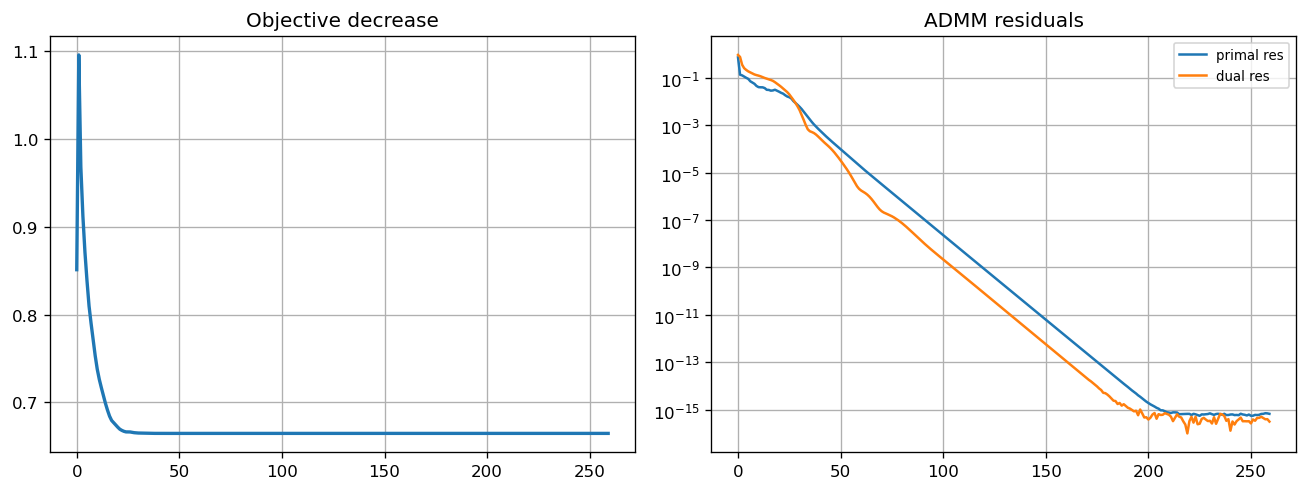

In [2]:
rng = np.random.default_rng(2)
m, n = 85, 230
A = rng.standard_normal((m, n))/np.sqrt(m)
x_true = np.zeros(n)
supp = rng.choice(n, 13, replace=False)
x_true[supp] = rng.standard_normal(13)
y = A @ x_true + 0.01*rng.standard_normal(m)

lam = 0.06
rho = 1.0
AtA = A.T @ A
P = np.linalg.inv(AtA + rho*np.eye(n))
Aty = A.T @ y

x = np.zeros(n); z = np.zeros(n); u = np.zeros(n)
primal=[]; dual=[]; obj=[]
for _ in range(260):
    x = P @ (Aty + rho*(z-u))
    z_old = z.copy()
    z = np.sign(x+u)*np.maximum(np.abs(x+u)-lam/rho, 0)
    u = u + x - z
    primal.append(np.linalg.norm(x-z))
    dual.append(np.linalg.norm(rho*(z-z_old)))
    obj.append(0.5*np.linalg.norm(A@x-y)**2 + lam*np.linalg.norm(z,1))

fig, axes = plt.subplots(1,2, figsize=(11,4.2))
axes[0].plot(obj, lw=2); axes[0].set_title("Objective decrease")
axes[1].plot(primal, label="primal res")
axes[1].plot(dual, label="dual res")
axes[1].set_yscale("log"); axes[1].legend(fontsize=8)
axes[1].set_title("ADMM residuals")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- D. Gabay, B. Mercier, "A Dual Algorithm for the Solution of Nonlinear Variational Problems", 1976.
- R. Glowinski, A. Marrocco, "Sur l'approximation ... par pénalisation-dualité", 1975.
- S. Boyd et al., "Distributed Optimization and Statistical Learning via ADMM", Foundations and Trends in ML, 2011.
